$${\color{yellow}{\text{MDS6304 Deep Learning Webinar-6}}}$$



---

Load essential libraries

---

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
plt.style.use('dark_background')
%matplotlib inline
import sys
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

---

Mount Google Drive folder if running Google Colab

---

In [ ]:
## Mount Google drive folder if running in Colab
if('google.colab' in sys.modules):
    from google.colab import drive
    drive.mount('/content/drive', force_remount = True)
    DIR = '/content/drive/MyDrive/Colab Notebooks/MAHE/Office of Online Education/MDS6304_Webinar_October2025'
    DATA_DIR = DIR+'/Data/'
else:
    DATA_DIR = '/Users/Sujata/Documents/data/'

---

Automatic differentiation in PyTorch.

Example: calculate the sensitivity of $L(w) = 4w+w^3$ w.r.t. the input $w$ at $w=1.$

Sensitivity $\nabla_wL = 4+3w^2,$ which at $w=1$ is equal to $4+3\times1^2=7.$

---

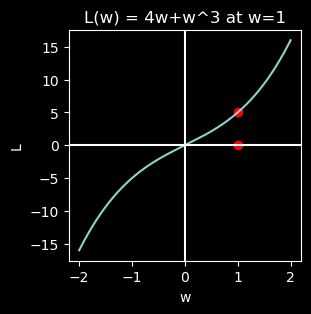

The gradient of L w.r.t. w at w = 1 is 7.000000


In [2]:
# 1. Create linspace and define function L(w)
w_vals = torch.linspace(-2, 2, 1000)
L_fn = lambda w: 4 * w + w ** 3

# 2. Plot L(w)
fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(w_vals, L_fn(w_vals))
ax.set_xlabel('w')
ax.set_ylabel('L')
ax.axhline(y = 0, color = 'white')
ax.axvline(x = 0, color = 'white')

# Mark L(1)
ax.set_title('L(w) = 4w+w^3 at w=1')
ax.scatter(1, L_fn(torch.tensor(1.0)), c = 'red')
ax.scatter(1, 0, c='red')
plt.show()

# 3. Compute gradient of L at w = 1
w = torch.tensor(1.0, requires_grad = True) # trainable tensor
L = 4 * w + w ** 3
L.backward()  # Compute gradient a.k.a sensitivity
print('The gradient of L w.r.t. w at w = 1 is %f' % w.grad.item())

---

Another example with a negative gradient.

Calculate the sensitivity of $L(w) = 4w-w^3$ w.r.t. the input $w$ at $w=1.5.$

Sensitivity $\nabla_wL = 4-3w^2,$ which at $w=1.5$ is equal to $4-3\times1.5^2=-2.75.$

---

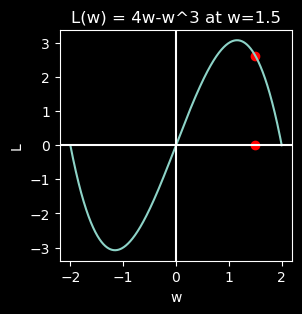

The gradient of L w.r.t. w at w = 1.5 is -2.750000


In [3]:
# 1. Create linspace and define function L(w)
w_vals = torch.linspace(-2, 2, 1000)
L_fn = lambda w: 4 * w - w ** 3

# 2. Plot L(w)
fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(w_vals, L_fn(w_vals))
ax.set_xlabel('w')
ax.set_ylabel('L')
ax.axhline(y = 0, color = 'white')
ax.axvline(x = 0, color = 'white')

# Mark L(1)
ax.set_title('L(w) = 4w-w^3 at w=1.5')
ax.scatter(1.5, L_fn(torch.tensor(1.5)), c = 'red')
ax.scatter(1.5, 0, c='red')
plt.show()

# 3. Compute gradient of L at w = 1.5
w = torch.tensor(1.5, requires_grad = True)
L = 4 * w - w ** 3
L.backward()  # Compute gradient a.k.a. sensitivity
print('The gradient of L w.r.t. w at w = 1.5 is %f' % w.grad.item())

---

Function with multiple inputs.

Example: calculate the sensitivity of $L(w_1,w_2) = w_1+w_2^2$ w.r.t. the inputs $w_1, w_2$ at $w_1=1, w_2=2.$

Setting $\mathbf{w} = \begin{bmatrix}w_1\\w_2\end{bmatrix},$ sensitivity $\nabla_\mathbf{w}L= \begin{bmatrix}\nabla_{w_1}(w_1+w_2^2)\\\nabla_{w_2}(w_1+w_2^2)\end{bmatrix} = \begin{bmatrix}\nabla_{w_1}(w_1)+\nabla_{w_1}(w_2^2)\\\nabla_{w_2}(w_1)+\nabla_{w_2}(w_2^2)\end{bmatrix} =\begin{bmatrix}1+0\\0+2w_2\end{bmatrix}=\begin{bmatrix}1\\2w_2\end{bmatrix},$

 which at $w_1=1,w_2=2$ is equal to $\begin{bmatrix}1\\4\end{bmatrix}.$

 ---

In [4]:
# Define variables with gradient tracking
w1 = torch.tensor(1.0, requires_grad = True)
w2 = torch.tensor(2.0, requires_grad = True)

# Compute the function
L = w1 + w2**2

# Compute gradients
L.backward()

# Print gradients
print([w1.grad.item(), w2.grad.item()])

[1.0, 4.0]


---

In the previous example, we could also calculate the sensitivity w.r.t. all the variables in the vector in one shot.

---

In [5]:
# Define variables as a vector with gradient tracking
w = torch.tensor([1.0, 2.0], requires_grad = True) # rank-2 tensor

# Compute the function
L = w[0] + w[1]**2

# Compute gradients
L.backward()

# Print gradients
print(w.grad)

tensor([1., 4.])


---

Another example of using a tensor variable as input where we calculate the sensitivity w.r.t. all the variables in the tensor:.

Consider calculating the sensitivity of $L(\mathbf{w}) = \lVert \mathbf{w}\rVert^2$ for an $8$-vector $w$ at $\tiny w=\begin{bmatrix}0.1\\0\\0.1\\0\\0.1\\0\\0.1\\0\end{bmatrix}.$

We know that $\nabla_\mathbf{w}\left(\lVert\mathbf{w}\rVert^2\right)=2\mathbf{w}$ which evaluated at $\tiny w=\begin{bmatrix}0.1\\0\\0.1\\0\\0.1\\0\\0.1\\0\end{bmatrix}$ is $\tiny2\begin{bmatrix}0.1\\0\\0.1\\0\\0.1\\0\\0.1\\0\end{bmatrix}=\begin{bmatrix}0.2\\0\\0.2\\0\\0.2\\0\\0.2\\0\end{bmatrix}.$

---

In [6]:
# Define variables as a vector with gradient tracking
w = torch.tensor([0.1, 0.0, 0.1, 0.0, 0.1, 0.0, 0.1, 0.0], requires_grad = True)

# Compute the function
L = torch.norm(w)**2

# Compute gradients
L.backward()

# Print gradients
print(w.grad)

tensor([0.2000, 0.0000, 0.2000, 0.0000, 0.2000, 0.0000, 0.2000, 0.0000])


---

Gradient calculation in PyTorch when a

- variable is part of the computation graph
- variable is marked non-trainable
- variable is not used at all
- variable is wrapped in tensor arithmetic (becoming a constant)

---

In [9]:
# Independent variable
w1 = torch.tensor(1.0, requires_grad = True)

# Constant tensor (non-trainable)
c1 = torch.tensor(-2.0)

# Variable treated as constant (no gradient tracking)
w2 = torch.tensor(2.0, requires_grad = False)

# Variable + constant → becomes a tensor, no gradient tracking
c2 = torch.tensor(10.0, requires_grad = True) + 1.0  # treated as constant now

# Unused variable
w3 = torch.tensor(0.0, requires_grad = True)

# Forward computation
L = (w1 + c1)**2 + w2**3 + 4 * c2

# Backward
L.backward()

# Gradients
print(w1.grad)   # Used in computation
print(w2.grad)   # Not tracked (requires_grad = False)
print(w3.grad)   # Unused in L
print(c1.grad)   # c1 is a constant (no grad tracking in PyTorch)
print(c2.grad)   # c2 is a tensor (not a leaf with grad_fn)

tensor(-2.)
None
None
None
None


C:\Users\sudarsan.acharya\AppData\Local\Temp\ipykernel_17600\3003068589.py:27: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\build\aten\src\ATen/core/TensorBody.h:494.)
  print(c2.grad)   # c2 is a tensor (not a leaf with grad_fn)


---

Example: consider calculating the gradient of $\mathbf{a}(z) = \begin{bmatrix}a_1(z)\\a_2(z)\end{bmatrix}  = \begin{bmatrix}2z\\z^4\end{bmatrix}$ at $z = -1.$

The gradient is $\nabla_z(\mathbf{a})= \begin{bmatrix}\nabla_z(a_1) & \nabla_z(a_2)\end{bmatrix}=\begin{bmatrix}\nabla_z(2z) & \nabla_z\left(z^4\right)\end{bmatrix}=\begin{bmatrix}2&4z^3\end{bmatrix}.$

Note that the sum of the gradients $\nabla_z(a_1)+\nabla_z(a_2)=2+4z^3$ for $z=-1$ is returned which is equal to $2+4(-1)^3=-2.$

---

In [ ]:
z = torch.tensor([-1.0], requires_grad = True)

# Forward computation
a = ?

# Backward
?

# Gradients
print(a.grad)

---

Applying the gradient descent method with

- a maximum number of iterations equal to 10000
- a stopping tolerance equal to $10^{-6}$
- a learning rate of 0.01

 to minimize $$L(\mathbf{w}) = (w_1-2)^2+(w_2+3)^2$$ starting from $\mathbf{w} = \begin{bmatrix}w_1\\w_2\end{bmatrix}=\begin{bmatrix}0.01\\-0.01\end{bmatrix}.$

---

In [14]:
# Initialize weights as tensors with gradients
w = torch.tensor([0.01, -0.01], requires_grad = True)

# Hyperparameters
maxiter = 500
tol = 1e-05
lr = 1e-02
norm_grad = float('inf')

k = 0
while k < maxiter and norm_grad > tol:
    # Zero the gradients
    if w.grad is not None:
        w.grad.zero_()

    # Define the loss function
    L = (w[0] - 2)**2 + (w[1] + 3)**2

    # Backpropagate to compute gradients
    L.backward()

    # Update weights using gradient descent
    with torch.no_grad():
        #w = w + lr * (-w.grad)
        w -= lr * w.grad

    # Compute the norm of the gradient
    norm_grad = w.grad.norm().item()
    k += 1

    print(f'Iteration {k}: ||grad|| = {norm_grad}')

Iteration 1: ||grad|| = 7.1833696365356445
Iteration 2: ||grad|| = 7.039702415466309
Iteration 3: ||grad|| = 6.8989081382751465
Iteration 4: ||grad|| = 6.760930061340332
Iteration 5: ||grad|| = 6.625711441040039
Iteration 6: ||grad|| = 6.493197441101074
Iteration 7: ||grad|| = 6.363333225250244
Iteration 8: ||grad|| = 6.236066818237305
Iteration 9: ||grad|| = 6.111345291137695
Iteration 10: ||grad|| = 5.989118576049805
Iteration 11: ||grad|| = 5.869336128234863
Iteration 12: ||grad|| = 5.751949310302734
Iteration 13: ||grad|| = 5.636910438537598
Iteration 14: ||grad|| = 5.524172306060791
Iteration 15: ||grad|| = 5.413688659667969
Iteration 16: ||grad|| = 5.30541467666626
Iteration 17: ||grad|| = 5.199306964874268
Iteration 18: ||grad|| = 5.095320224761963
Iteration 19: ||grad|| = 4.993413925170898
Iteration 20: ||grad|| = 4.893545627593994
Iteration 21: ||grad|| = 4.795674800872803
Iteration 22: ||grad|| = 4.699761390686035
Iteration 23: ||grad|| = 4.605766296386719
Iteration 24: ||gra

In [15]:
# Print the optimal parameter values
w

tensor([ 1.9999, -2.9999], requires_grad=True)


**The patient data matrix with output labels and initial weight matrix**

![patient dataset](https://1drv.ms/i/s!AjTcbXuSD3I3hspfrgklysOtJMOjaA?embed=1&width=800)

In [17]:
# Patients data matrix
X = torch.tensor([[72, 120, 37.3, 104, 32.5],
                 [85, 130, 37.0, 110, 14],
                 [68, 110, 38.5, 125, 34],
                 [90, 140, 38.0, 130, 26],
                 [84, 132, 38.3, 146, 30],
                 [78, 128, 37.2, 102, 12]], dtype = torch.float64)
print(f'Patient data matrix X:\n {X}') 
print('-----')

# Initial Weights matrix (trainable tensor)
W = torch.tensor([[-0.1, 0.5, 0.3],
                  [0.9, 0.3, 0.5],
                  [-1.5, 0.4, 0.1],
                  [0.1, 0.1, -1.0],
                  [-1.2, 0.5, -0.8]], dtype = torch.float64,
                 requires_grad = True)
print(f'Weights matrix:\n {W}')
print('-----')

# Create a 1D-numpy array of output labels (equivalent to a rank-1 tensor in
# PyTorch which itself is equivalent to a vector in pen & paper)
y = np.array(['non-diabetic',
              'diabetic',
              'non-diabetic',
              'pre-diabetic',
              'diabetic',
              'pre-diabetic'])
# Creating a one-hot encoder object
ohe = OneHotEncoder(sparse_output = False)
# Create the one-hot encoded true output labels matrix
Y = torch.tensor(ohe.fit_transform(y.reshape(-1, 1)), dtype = torch.float64)
print(f'One-hot encoded output labels matrix:\n {Y}')
print('-----')

# Standardize the data
sc = StandardScaler() # create a standard scaler object
X_std = torch.tensor(sc.fit_transform(X), dtype = torch.float64)
print(f'The standardized data matrix:\n{X_std}')

Patient data matrix X:
 tensor([[ 72.0000, 120.0000,  37.3000, 104.0000,  32.5000],
        [ 85.0000, 130.0000,  37.0000, 110.0000,  14.0000],
        [ 68.0000, 110.0000,  38.5000, 125.0000,  34.0000],
        [ 90.0000, 140.0000,  38.0000, 130.0000,  26.0000],
        [ 84.0000, 132.0000,  38.3000, 146.0000,  30.0000],
        [ 78.0000, 128.0000,  37.2000, 102.0000,  12.0000]],
       dtype=torch.float64)
-----
Weights matrix:
 tensor([[-0.1000,  0.5000,  0.3000],
        [ 0.9000,  0.3000,  0.5000],
        [-1.5000,  0.4000,  0.1000],
        [ 0.1000,  0.1000, -1.0000],
        [-1.2000,  0.5000, -0.8000]], dtype=torch.float64, requires_grad=True)
-----
One-hot encoded output labels matrix:
 tensor([[0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 0., 1.]], dtype=torch.float64)
-----
The standardized data matrix:
tensor([[-0.9799, -0.7019, -0.7238, -0.9871,  0.8920],
        [ 0.7186,  0.3509, -1.2449, -0.6050, -1

---

Using PyTorch, calculate the optimal weights for the patient data matrix


---

In [18]:
# Define optimizer
optimizer = torch.optim.Adam([W], lr = 1e-02)

# Loss function
def loss_fn(X):
  # Raw scores
  Z = X @ W # same as torch.matmul(X, W)

  # Softmax-activated scores
  softmax = torch.nn.Softmax(dim = 1)
  A = softmax(Z)

  # Calculate the average training loss
  L = torch.mean(-torch.log(torch.sum(Y*A, dim = 1)))
  return L

# Optimization loop
num_epochs = 1000
loss_train = np.empty(num_epochs)
for epoch in range(num_epochs):
  # Zero out the gradients
  optimizer.zero_grad()

  # Forward propagation (loss calculation)
  loss = loss_fn(X_std)

  # Backward propagation and optimization
  loss.backward() # calculate the gradients
  optimizer.step() # update the weights

  # Print the loss every epoch
  loss_train[epoch] = loss.item()
  print(f'Epoch {epoch}, loss = {loss.item()}')

Epoch 0, loss = 1.2303940464309857
Epoch 1, loss = 1.1988313475082657
Epoch 2, loss = 1.167915792731229
Epoch 3, loss = 1.1376693687102686
Epoch 4, loss = 1.1081117180199922
Epoch 5, loss = 1.0792594547734682
Epoch 6, loss = 1.051125410402977
Epoch 7, loss = 1.0237179935424643
Epoch 8, loss = 0.9970410294736309
Epoch 9, loss = 0.9710944500764948
Epoch 10, loss = 0.9458757634604371
Epoch 11, loss = 0.9213816024250634
Epoch 12, loss = 0.8976086102734903
Epoch 13, loss = 0.8745535546990616
Epoch 14, loss = 0.8522130590672475
Epoch 15, loss = 0.8305833146578808
Epoch 16, loss = 0.809659899940843
Epoch 17, loss = 0.7894376848482066
Epoch 18, loss = 0.7699107683767544
Epoch 19, loss = 0.7510724162937454
Epoch 20, loss = 0.7329149877051635
Epoch 21, loss = 0.7154298533273726
Epoch 22, loss = 0.6986073148970725
Epoch 23, loss = 0.6824365365387708
Epoch 24, loss = 0.6669054973110501
Epoch 25, loss = 0.6520009713741465
Epoch 26, loss = 0.63770853937298
Epoch 27, loss = 0.6240126321543263
Epoch 2

---

Plot training loss curve

---

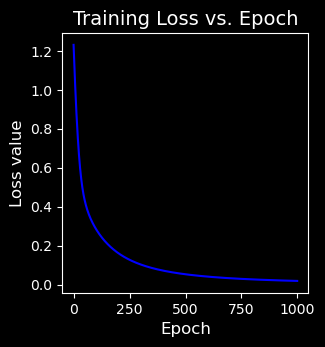

In [19]:
## Plot train loss as a function of epoch:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
fig.tight_layout(pad = 4.0)
ax.plot(loss_train, 'b')
ax.set_xlabel('Epoch', fontsize = 12)
ax.set_ylabel('Loss value', fontsize = 12)
ax.set_title('Training Loss vs. Epoch', fontsize = 14);

In [ ]:
# Optimal weights after training
W

tensor([[ 2.3990, -1.0268,  1.1558],
        [-2.3522, -1.2947,  3.0253],
        [-2.3237, -1.0213,  5.3735],
        [ 2.1537, -1.6400, -6.7106],
        [-1.1512,  2.6423, -1.0289]], dtype=torch.float64, requires_grad=True)

---

How good are the weights when applied to the training data?

---

In [22]:
with torch.no_grad():
  # Raw scores 
  Z = X_std @ W

  # Softmax-activated scores 
  softmax = torch.nn.Softmax(dim = 1)
  A = softmax(Z)

# Get predicted labels 
print(f'Predicted labels for training data: {A.argmax(dim = 1)}')

# True output labels
print(f'True output labels: {Y.argmax(dim = 1)}')

Predicted labels for training data: tensor([1, 0, 1, 2, 0, 2])
True output labels: tensor([1, 0, 1, 2, 0, 2])


---

The ReLU (rectified linear unit) non-linear activation function: $$\begin{align*}g(z)&=\begin{cases}z,&\text{if }z\geq0,\\0,&\text{if }z<0.\end{cases}\end{align*}$$

Lets non-negative raw scores flow through and clips negative raw scores to zero:

![ReLU graph](https://1drv.ms/i/c/37720f927b6ddc34/IQQ2LpqSl9JMSKCzneksEc8CAXrRgpiM7O00yEnO9YUtbZA?width=562&height=200)

---

In [ ]:
# User-defined function for pointwise ReLU activation
def ReLU(z):
  return ?

---

A one-hidden layer neural network, or equivalently a 2-layer neural network with pointwise ReLU activation for the hidden layer:


![2-layer neural network](https://1drv.ms/i/c/37720f927b6ddc34/IQTcIoux_NYvTKiIUEK_P3ffAY0ViDllOLNX8bhgeWSqE5g?width=660)



---

In [ ]:
# Calculate raw scores for layer-1 by randomly initializing the weights matrix for layer-1
W1 = ?
Z1 = ?
print(f'The raw scores matrix for layer-1 with shape {list(Z1.shape)}:\n{Z1}')
print('-----')

# ReLU-activate the raw scores in layer-1
A1 = ?
print(f'The ReLU-activated scores matrix for layer-1 with shape {list(A1.shape)}:\n{A1}')
print('-----')

# Calculate raw scores for layer-2 by randomly initializing the weights matrix for layer-2
W2 = ?
Z2 = ?
print(f'The raw scores matrix for layer-2 with shape {list(Z2.shape)}:\n{Z2}')
print('-----')

# Softmax-activate the raw scores in layer-2
softmax = torch.nn.Softmax(dim = 1)
A2 = ?
print(f'The softmax-activated scores matrix for layer-2 with shape {list(A2.shape)}:\n{A2}')

---

Using PyTorch, calculate the optimal weights $\mathbf{W}^{[1]}$ and $\mathbf{W}^{[2]}$ for the 2-layer neural network

---



In [ ]:
# Create dictionary of weights
W = ?

# Define optimizer
optimizer = torch.optim.Adam(W.items(), lr = 1e-02)

# Loss function
def loss_fn(X):
  # Raw scores for layer-1
  Z1 = ?

  # ReLU-activated scores for layer-1
  A1 = ?

  # Raw scores for layer-2
  Z2 = ?

  # Softmax-activated scores for layer-2
  softmax = torch.nn.S?softmax(Z2)

  # Calculate the average training loss
  L = ?
  return L

# Optimization loop
num_epochs = 1000
loss_train = np.empty(num_epochs)
for epoch in range(num_epochs):
  # Zero out the gradients
  optimizer.?

  # Forward propagation (loss calculation)
  loss = ?

  # Backward propagation and optimization
  loss.?
  optimizer.?

  # Print the loss every epoch
  loss_train[epoch] = loss.item()
  print(f'Epoch {epoch}, loss = {loss_train[epoch]}')

---

Plot training loss curve

---

In [ ]:
## Plot train loss as a function of epoch:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
fig.tight_layout(pad = 4.0)
ax.plot(loss_train, 'b')
ax.set_xlabel('Epoch', fontsize = 12)
ax.set_ylabel('Loss value', fontsize = 12)
ax.set_title('Training Loss vs. Epoch', fontsize = 14);

---

How good are the trained weights when applied to the training data?

---

In [ ]:
with torch.no_grad():
  # Raw scores for layer-1
  Z1 = ?

  # ReLU-activated scores for layer-1
  A1 = ?

  # Raw scores for layer-2
  Z2 = ?

  # Softmax-activated scores for layer-2
  softmax = torch.nn.Softmax(dim = 1)
  A2 = ?

# Get predicted labels 
print(f'Predicted labels for training data: {?}')

# True output labels
print(f'True output labels: {?}')

---

Loading the Bengaluru Hosueprice dataset and performing a train-test split

---

In [ ]:
## Load housing data
file = DATA_DIR+'houseprices_cleaned.csv'
df= pd.read_csv(file, header = 0).dropna()

## Train and test split of the data
X = df[['area', 'rent']]
y = df['price_per_sqft']
X_train, X_test, Y_train, Y_test = ?
# Standardize data
sc = StandardScaler()
X_train = ?
X_test = ?

# Convert train and test data to numpy arrays (note that Y should be a 1-column matrix)
X_train = torch.tensor(X_train, dtype = torch.float64)
X_test = torch.tensor(X_test, dtype = torch.float64)
Y_train = torch.tensor(Y_train.values, dtype = torch.float32).reshape(-1, 1)
Y_test = torch.tensor(Y_test.values, dtype = torch.float32).reshape(-1, 1)

num_samples = X_train.shape[0]
num_features = X_train.shape[1]

print('Housing data set')
print('---------------------')
print('Number of training samples = %d'%(num_samples))
print('Number of features = %d'%(num_features))

---

Using PyTorch, calculate the optimal weights $\mathbf{W}^{[1]}$ and $\mathbf{W}^{[2]}$ for the 2-layer neural network

---



In [ ]:
# Create dictionary of weights
W = ?

# Define optimizer
optimizer = torch.optim.Adam(W.items(), lr = 1e-02)

# Loss function
def loss_fn(?, ?):
  # Raw scores for layer-1
  Z1 = ?

  # ReLU-activated scores for layer-1
  A1 = ?

  # Raw scores for layer-2
  Z2 = ?

  # Calculate the average training loss
  L = ?
  return L

# Optimization loop
num_epochs = 50000
loss_train = np.empty(num_epochs)
loss_test = np.empty(num_epochs)
for epoch in range(num_epochs):
  # Zero out the gradients
  optimizer.zero_grad()

  # Forward propagation (loss calculation)
  loss = ?   

  # Backward propagation and optimization
  loss.?
  optimizer.?

  # Print the loss every 1000 epochs
  loss_train[epoch] = loss.item()
  # Test loss
  with torch.no_grad():
    loss = ?
    loss_test[epoch] = loss.item()
  if epoch % 1000 == 0:
    print(f'Epoch {epoch}, train loss = {loss_train[epoch]}, test loss = {loss_test[epoch]}')

---

Plot train and test loss curves

---

In [ ]:
## Plot train and test loss as a function of epoch:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
fig.tight_layout(pad = 4.0)
ax.plot(loss_train, 'b', label = 'Train')
ax.plot(loss_test, 'r', label = 'Test')
ax.set_xlabel('Epoch', fontsize = 12)
ax.set_ylabel('Loss value', fontsize = 12)
ax.legend()
ax.set_title('Loss vs. Epoch', fontsize = 14);

---

How good are the trained weights when applied to the test data?

---

In [ ]:
with torch.no_grad():
  # Raw scores for layer-1
  Z1 = ?

  # ReLU-activated scores for layer-1
  A1 = ?

  # Raw scores for layer-2
  Z2 = ?      

print(f'Test data true and predicted house prices {?}')
